### Dataset

In [ ]:
import os

import numpy as np
import pandas as pd
from collections import Counter

import tensorflow as tf
from tensorflow import keras
import keras_tuner as kt

# Resto degli imports...
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, label_binarize
from sklearn.metrics import (
    classification_report, 
    f1_score, 
    confusion_matrix,
    roc_curve, 
    auc,
    precision_recall_fscore_support
)

import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [2]:
# df_train = pd.read_csv('/Users/chiaracap/Downloads/train_cleaned_outliers.csv')
# df_train = df_train.drop('originalTitle', axis=1)
# df_train = df_train.drop('averageRating', axis=1)

# df_test = pd.read_csv('/Users/chiaracap/Downloads/test_no_title.csv')
# df_test = df_test.drop('averageRating', axis=1)
# print(df_test.head())

df_train = pd.read_csv('../train_set/train_cleaned_outliers.csv')
df_test = pd.read_csv('../test_set/test_no_title.csv')

# drop column originalTitle
df_train = df_train.drop('originalTitle', axis=1)

### Mappatura etichette

In [3]:
# # change all 1, 2, 3 in 4
df_train['rating'] = df_train['rating'].replace([1, 2, 3], 4)
df_test['rating'] = df_test['rating'].replace([1, 2, 3], 4)

# # replace all 10 with 9
df_train['rating'] = df_train['rating'].replace(10, 9)
df_test['rating'] = df_test['rating'].replace(10, 9)

In [4]:
# # From ratings 4 to 9, we want to map them to 0 to 5
label_mapping = {4: 0, 5: 1, 6: 2, 7: 3, 8: 4, 9: 5}

df_train['rating'] = df_train['rating'].map(label_mapping)
df_test['rating'] = df_test['rating'].map(label_mapping)

### Validation set e test set

In [5]:
X = df_train.drop(columns=['rating', 'averageRating'])
y = df_train['rating']

In [6]:
X_test = df_test.drop(columns=['rating','averageRating', 'genreShort'])
y_test = df_test['rating']

In [7]:
# Suddivisione con stratificazione
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,  # 20% per la validazione
    stratify=y,     # Mantiene la distribuzione delle classi
    random_state=42 # Per riproducibilità
)
# print unique values in y_train, y_val, y_test
print("Unique values in y_train:", np.unique(y_train))
print("Unique values in y_val:", np.unique(y_val))
print("Unique values in y_test:", np.unique(y_test))


Unique values in y_train: [0 1 2 3 4 5]
Unique values in y_val: [0 1 2 3 4 5]
Unique values in y_test: [0 1 2 3 4 5]


### Normalizzazione con MinMax scaler

In [8]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

### Tuning of parameters

In [ ]:
# def build_simple_model(hp):
#     model = keras.Sequential()
    
#     # Primo layer
#     model.add(keras.layers.Dense(
#         units=hp.Int('units_1', min_value=256, max_value=512, step=64),  # Aumenta il range
#         activation='relu',
#         input_shape=(X_train.shape[1],)
#     ))
#     model.add(keras.layers.Dropout(rate=hp.Float('dropout_1', 0.2, 0.5, step=0.1)))
    
#     # Secondo layer opzionale
#     if hp.Boolean('second_layer'):
#         model.add(keras.layers.Dense(
#             units=hp.Int('units_2', min_value=64, max_value=128, step=32),  # Aumenta il range
#             activation='relu'
#         ))
#         model.add(keras.layers.Dropout(rate=hp.Float('dropout_2', 0.2, 0.4, step=0.1)))
    
#     # Terzo layer opzionale per relazioni complesse
#     if hp.Boolean('third_layer'):
#         model.add(keras.layers.Dense(
#             units=hp.Int('units_3', min_value=32, max_value=64, step=16),  # Nuovo layer
#             activation='relu'
#         ))
#         model.add(keras.layers.Dropout(rate=hp.Float('dropout_3', 0.2, 0.4, step=0.1)))
    


#     # Output layer
#     model.add(keras.layers.Dense(6, activation='softmax'))
    
#     # Optimizer semplice
#     model.compile(
#         optimizer=keras.optimizers.Adam(
#             learning_rate=hp.Choice('learning_rate', [1e-4])  # Aggiungi valori più alti
#         ),
#         loss='sparse_categorical_crossentropy',
#         metrics=['sparse_categorical_accuracy']
#     )
#     return model

# # TUNER SEMPLICE
# tuner = kt.RandomSearch(
#     build_simple_model,
#     objective='val_sparse_categorical_accuracy',
#     max_trials=20,  # Ridotto per velocità
#     executions_per_trial=3,
#     directory='simple_tuning_reset',
#     project_name='simple_reset',
#     overwrite=True
# )

# # CALLBACKS SEMPLICI
# callbacks = [
#     keras.callbacks.EarlyStopping(
#         monitor='val_loss',  # Cambia da 'val_accuracy' a 'val_loss'
#         patience=10,
#         restore_best_weights=True
#     ),
#     keras.callbacks.ReduceLROnPlateau(
#         monitor='val_loss',  # Cambia da 'val_accuracy' a 'val_loss'
#         factor=0.5,
#         patience=5,
#         min_lr=1e-4
#     )
# ]

# print(" INIZIO TUNING SEMPLICE...")

# # SEARCH
# tuner.search(
#     X_train_scaled, y_train,
#     batch_size=64,  # Prima 128
#     epochs=50,  # prima 40
#     validation_data=(X_val_scaled, y_val),
#     # class_weight=class_weight_dict,
#     callbacks=callbacks,
#     verbose=1
# )


In [ ]:

# # MIGLIORI PARAMETRI
# best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
# print("\n MIGLIORI PARAMETRI TROVATI:")
# for param, value in best_hps.values.items():
#     print(f"  {param}: {value}")

# # TRAINING FINALE SEMPLICE
# print("\n TRAINING MODELLO FINALE...")
# final_model = tuner.hypermodel.build(best_hps)

# history = final_model.fit(
#     X_train_scaled, y_train,
#     epochs=50,  # Aumenta il numero di epoche
#     validation_data=(X_val_scaled, y_val),
# #    class_weight=class_weight_dict,
#     callbacks=[
#         keras.callbacks.EarlyStopping(
#             monitor='val_loss',  # Cambia da 'val_accuracy' a 'val_loss'
#             patience=20,
#             restore_best_weights=True
#         )
#     ],
#     verbose=1
# )

NameError: name 'tuner' is not defined

In [ ]:
# # SALVA IL MODELLO (non la history!)
# final_model.save('./models/NN_rating_classifier/NN_rating_classifier.h5')


# # save best hyperparameters
# with open('./models/NN_rating_classifier/NN_rating_best_params.pkl', 'wb') as f:
#     pickle.dump(best_hps.values, f)

# # save history
# with open('./models/NN_rating_classifier/NN_rating_history.pkl', 'wb') as f:
#     pickle.dump(history.history, f)

# # save scaler
# with open('./models/NN_rating_classifier/NN_rating_scaler.pkl', 'wb') as f:
#     pickle.dump(scaler, f)

In [18]:
# load
final_model = keras.models.load_model('./models/NN_rating_classifier/NN_rating_classifier.h5')
# load scaler
with open('./models/NN_rating_classifier/NN_rating_scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# load history
with open('./models/NN_rating_classifier/NN_rating_history.pkl', 'rb') as f:
    history = pickle.load(f)

# load best hyperparameters
with open('./models/NN_rating_classifier/NN_rating_best_params.pkl', 'rb') as f:
    best_hps = pickle.load(f)

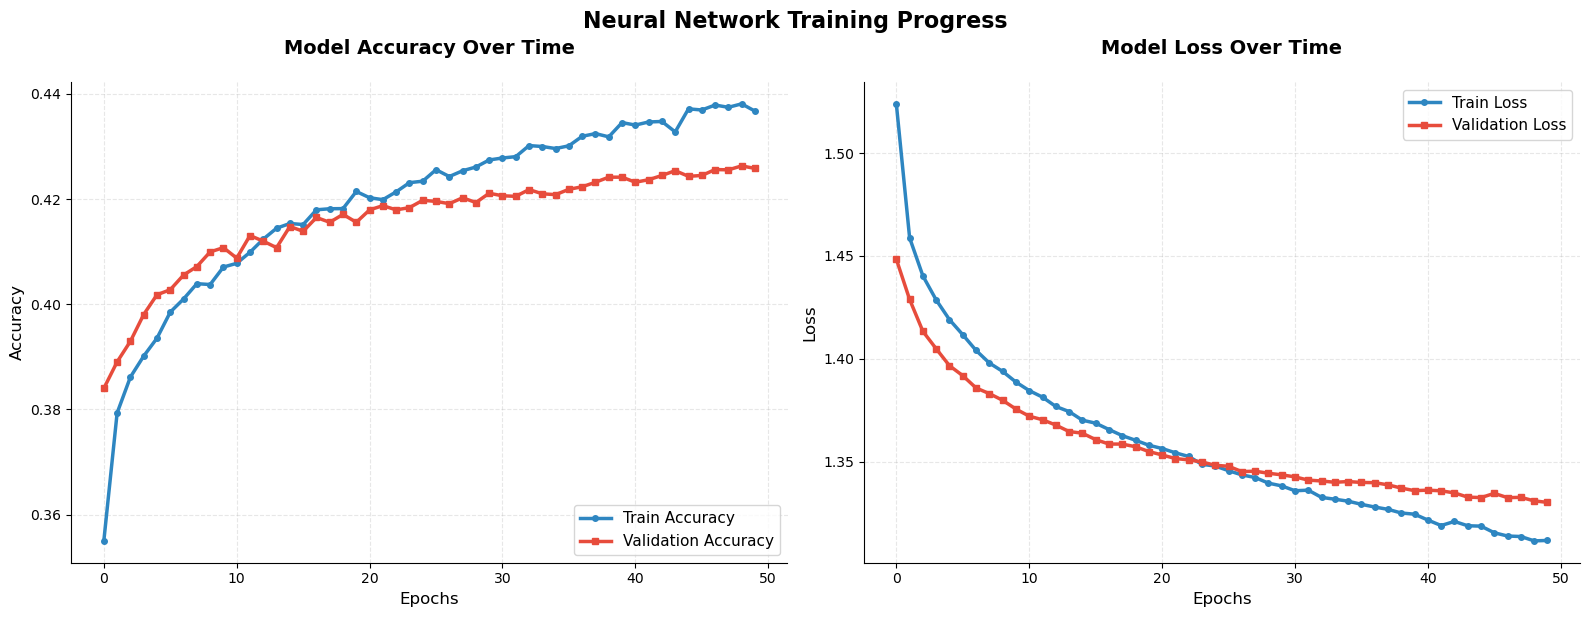

In [ ]:
# PLOT AFFIANCATI CON STILE PROFESSIONALE
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Color palette
train_color = '#2E86C1'  # Blu
val_color = '#E74C3C'    # Rosso

# ACCURACY PLOT
# Rimuovi .history perché history è già un dizionario
axes[0].plot(history['sparse_categorical_accuracy'], 
             color=train_color, linewidth=2.5, label='Train Accuracy', marker='o', markersize=4)
axes[0].plot(history['val_sparse_categorical_accuracy'], 
             color=val_color, linewidth=2.5, label='Validation Accuracy', marker='s', markersize=4)

axes[0].set_title('Model Accuracy Over Time', fontsize=14, fontweight='bold', pad=20)
axes[0].set_xlabel('Epochs', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(loc='lower right', fontsize=11)
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# LOSS PLOT
# Rimuovi .history perché history è già un dizionario
axes[1].plot(history['loss'], 
             color=train_color, linewidth=2.5, label='Train Loss', marker='o', markersize=4)
axes[1].plot(history['val_loss'], 
             color=val_color, linewidth=2.5, label='Validation Loss', marker='s', markersize=4)

axes[1].set_title('Model Loss Over Time', fontsize=14, fontweight='bold', pad=20)
axes[1].set_xlabel('Epochs', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(loc='upper right', fontsize=11)
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# STYLING FINALE
plt.suptitle('Neural Network Training Progress', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.subplots_adjust(top=0.9)  # Spazio per il titolo
plt.show()

In [23]:
# Valutazione del modello
train_acc = final_model.evaluate(X_train_scaled, y_train, verbose=0)[1]
val_acc = final_model.evaluate(X_val_scaled, y_val, verbose=0)[1]
test_acc = final_model.evaluate(X_test_scaled, y_test, verbose=0)[1]

print(f"\n📊 PERFORMANCE FINALI:")
print(f"• Train Accuracy: {train_acc:.4f}")
print(f"• Validation Accuracy: {val_acc:.4f}")
print(f"• Test Accuracy: {test_acc:.4f}")


📊 PERFORMANCE FINALI:
• Train Accuracy: 0.4539
• Validation Accuracy: 0.4258
• Test Accuracy: 0.4270


1135/1135 [==============================] - 0s 424us/step


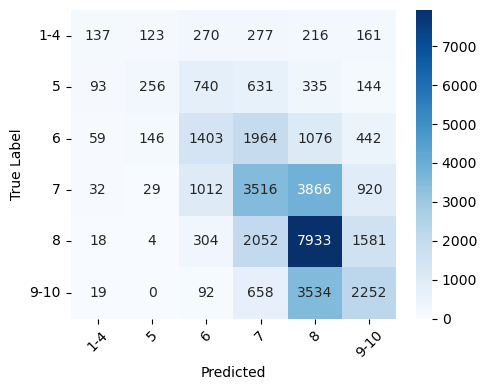

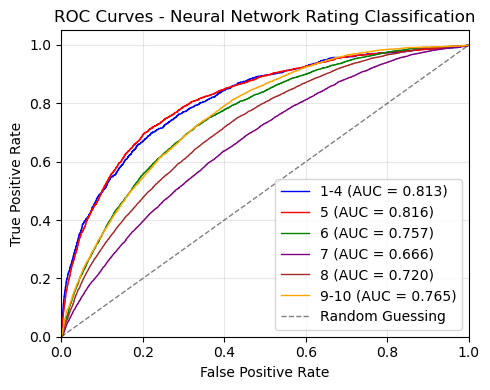


📋 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

         1-4       0.38      0.12      0.18      1184
           5       0.46      0.12      0.19      2199
           6       0.37      0.28      0.31      5090
           7       0.39      0.38      0.38      9375
           8       0.47      0.67      0.55     11892
        9-10       0.41      0.34      0.37      6555

    accuracy                           0.43     36295
   macro avg       0.41      0.32      0.33     36295
weighted avg       0.42      0.43      0.41     36295


🎯 RATING METRICS:
Mean Absolute Error (Rating): 0.798

📊 ERROR DISTRIBUTION:
  Error 0: 15497 samples (42.7%)
  Error 1: 15111 samples (41.6%)
  Error 2: 3947 samples (10.9%)
  Error 3: 1182 samples (3.3%)
  Error 4: 378 samples (1.0%)
  Error 5: 180 samples (0.5%)


In [ ]:
# ...existing code...
label_map = {
    0: "1-4",
    1: "5",
    2: "6",
    3: "7",
    4: "8",
    5: "9-10"
}

# 🔧 PREDIZIONI CORRETTE per Neural Network
y_pred_proba = final_model.predict(X_test_scaled)  # Probabilità da NN
y_pred = np.argmax(y_pred_proba, axis=1)  # Classi predette (0-5)

# CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))

# Crea le label per gli assi usando il mapping
class_labels = [label_map[i] for i in range(len(label_map))]

sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xticks(rotation=45)
plt.yticks(rotation=0)  # Mantieni orizzontali per leggibilità
plt.xlabel('Predicted')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# ROC CURVES
# Binarizza le etichette per multiclass ROC
y_test_bin = label_binarize(y_test, classes=sorted(np.unique(y_test)))
n_classes = y_test_bin.shape[1]

# Calcola le curve ROC e AUC per ogni classe
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])  # Usa probabilità NN
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot delle curve ROC
plt.figure(figsize=(5, 4))
colors = ['blue', 'red', 'green', 'purple', 'brown', 'orange']

for i in range(n_classes):
    plt.plot(
        fpr[i], tpr[i], 
        color=colors[i % len(colors)],
        lw=1,
        label=f'{label_map[i]} (AUC = {roc_auc[i]:.3f})'
    )

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Guessing', alpha=0.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Neural Network Rating Classification')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# CLASSIFICATION REPORT
from sklearn.metrics import classification_report
print("\n📋 CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, target_names=class_labels))

# METRICHE AGGIUNTIVE per rating
from sklearn.metrics import mean_absolute_error
y_test_rating = y_test + 4  # Convert to original rating (4-9)
y_pred_rating = y_pred + 4

mae = mean_absolute_error(y_test_rating, y_pred_rating)
print(f"\n🎯 RATING METRICS:")
print(f"Mean Absolute Error (Rating): {mae:.3f}")

# Distribuzione errori
errors = np.abs(y_test_rating - y_pred_rating)
print(f"\n📊 ERROR DISTRIBUTION:")
for error in sorted(np.unique(errors)):
    count = np.sum(errors == error)
    pct = count / len(errors) * 100
    print(f"  Error {error}: {count} samples ({pct:.1f}%)")